In [1]:
# import python libraries

import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib

In [11]:
# some values used for calculations

k = 8.61733e-5; # boltzmann constant in eV/K
TK = 1150+273; # equilibrium temp in K
TC = TK-273; # equilibrium temp in C
TQK = 500+273;# quenched temp in K
TQC = TQK-273; # quenched temp in C
a = np.logspace(-20,5,200); # oxygen partial pressure range
# print(
#     f'a[154] = {a[154]:.2} atm'
# ) # pO2~0.21 atm

In [12]:
# Equilibrium defect reaction constants

KR = 1.06E71*np.exp(-5.69/(k*TK))
# KR = 1.27E51 # at 1000C from "Defect structure and Fermi-level pinning of BaTiO3 co-doped with a variable-valence acceptor (Mn) and a fixed-valence donor (Y)"
Ki = 8.55E44*np.exp(-2.91/(k*TK))
KiQ = 8.55E44*np.exp(-2.91/(k*TQK))
KS = (3.4E105)*np.exp(-2.795/(k*TK))

# Lee, Soonil, Clive A. Randall, and Zi‐Kui Liu. "Comprehensive Linkage of Defect and Phase Equilibria through Ferroelectric Transition Behavior in BaTiO3‐Based Dielectrics: Part 1. Defect Energies Under Ambient Air Conditions." Journal of the American Ceramic Society 91, no. 6 (2008): 1748-1752.
KPSB = (1.15E22)**2*np.exp(10.15)*np.exp(-2.32/(k*TK)) # partial Schottky reaction on Ti-rich; [VBa2-] is fixed

# Hagemann, H‐J., and D. Hennings. "Reversible weight change of acceptor‐doped BaTiO3." Journal of the American Ceramic Society 64, no. 10 (1981): 590-594.
KMn43 = 2*2.0E22*np.exp(-(3.12-1.28)/(k*TK))
KMn43Q = 2*2.0E22*np.exp(-(3.12-1.28)/(k*TQK))
KMn32 = 1/2*2.0E22*np.exp(-(3.12-1.87)/(k*TK))
KMn32Q = 1/2*2.0E22*np.exp(-(3.12-1.87)/(k*TQK))

print(
    f'at T = {TC} \u00B0C\n'
    f'KS = {KS:.2e}\n'
    f'KPSB = {KPSB:.2e}\n'
    f'Ki = {Ki:.2e}\n'
    f'KiQ = {KiQ:.2e}\n'
    f'KR = {KR:.2e}\n'
    f'KMn43 = {KMn43:.2e}\n'
    f'KMn43Q = {KMn43Q:.2e}\n'
    f'KMn32 = {KMn32:.2e}\n'
    f'KMn32Q = {KMn32Q:.2e}'
)


at T = 1150 °C
KS = 4.29e+95
KPSB = 2.06e+40
Ki = 4.22e+34
KiQ = 9.11e+25
KR = 7.47e+50
KMn43 = 1.22e+16
KMn43Q = 4.03e+10
KMn32 = 3.74e+17
KMn32Q = 7.08e+13


In [13]:
print(Ki/KMn43)
print(Ki/KMn32)

3.47001612188368e+18
1.1293094156856032e+17


In [14]:
# empty lists for each defect concentration; will be filled later
# Mn+Y co-doped & A/B = 1.000 / 0.999 / 0.994 & high T eq / low T quenched

CVO2_MnY_1000e = np.zeros(len(a))
CVO2_MnY_1000q = np.zeros(len(a))
CVO2_MnY_999e = np.zeros(len(a))
CVO2_MnY_999q = np.zeros(len(a))
CVO2_MnY_994e = np.zeros(len(a))
CVO2_MnY_994q = np.zeros(len(a))

CVTi4_MnY_1000e = np.zeros(len(a))
CVTi4_MnY_1000q = np.zeros(len(a))
CVTi4_MnY_999e = np.zeros(len(a))
CVTi4_MnY_999q = np.zeros(len(a))
CVTi4_MnY_994e = np.zeros(len(a))
CVTi4_MnY_994q = np.zeros(len(a))

CVBa2_MnY_1000e = np.zeros(len(a))
CVBa2_MnY_1000q = np.zeros(len(a))
CVBa2_MnY_999e = np.zeros(len(a))
CVBa2_MnY_999q = np.zeros(len(a))
CVBa2_MnY_994e = np.zeros(len(a))
CVBa2_MnY_994q = np.zeros(len(a))

n_MnY_1000e = np.zeros(len(a))
n_MnY_1000q = np.zeros(len(a))
n_MnY_999e = np.zeros(len(a))
n_MnY_999q = np.zeros(len(a))
n_MnY_994e = np.zeros(len(a))
n_MnY_994q = np.zeros(len(a))

p_MnY_1000e = np.zeros(len(a))
p_MnY_1000q = np.zeros(len(a))
p_MnY_999e = np.zeros(len(a))
p_MnY_999q = np.zeros(len(a))
p_MnY_994e = np.zeros(len(a))
p_MnY_994q = np.zeros(len(a))

CMn0_MnY_1000e = np.zeros(len(a))
CMn1_MnY_1000e = np.zeros(len(a))
CMn2_MnY_1000e = np.zeros(len(a))

CMn0_MnY_1000q = np.zeros(len(a))
CMn1_MnY_1000q = np.zeros(len(a))
CMn2_MnY_1000q = np.zeros(len(a))

CMn0_MnY_999e = np.zeros(len(a))
CMn1_MnY_999e = np.zeros(len(a))
CMn2_MnY_999e = np.zeros(len(a))

CMn0_MnY_999q = np.zeros(len(a))
CMn1_MnY_999q = np.zeros(len(a))
CMn2_MnY_999q = np.zeros(len(a))

CMn0_MnY_994e = np.zeros(len(a))
CMn1_MnY_994e = np.zeros(len(a))
CMn2_MnY_994e = np.zeros(len(a))

CMn0_MnY_994q = np.zeros(len(a))
CMn1_MnY_994q = np.zeros(len(a))
CMn2_MnY_994q = np.zeros(len(a))

Mn+Y co-doped & A/B = 1.0 & T = 1150 °C
at pO2 ~ 0.21 atm
n = 1.05e+16
p = 4.02e+18
[VO2+] = 1.43e+19
[VBa2-] = 1.21e+19
[VTi4-] = 1.21e+19
[Mnt] = 7.70e+19
[Mn0] = 4.08e+19
[Mn1-] = 3.52e+19
[Mn2-] = 9.90e+17
[YBa1+] = 7.70e+19


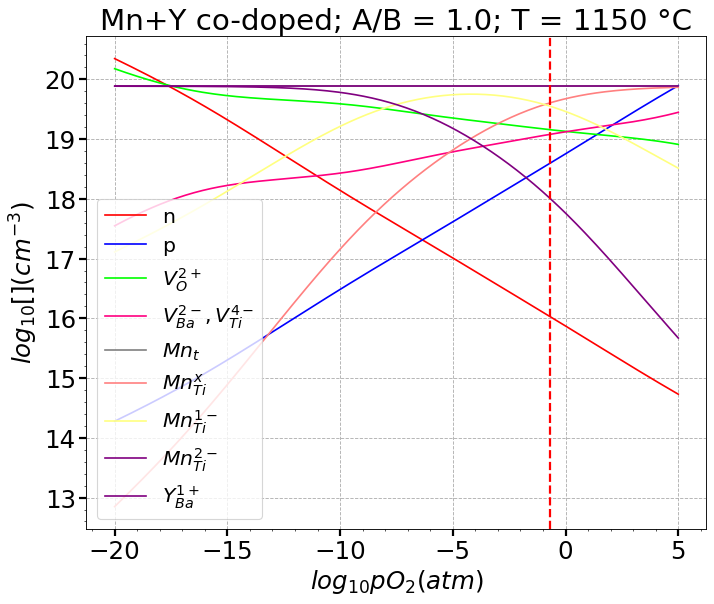

In [15]:
"""
[19] Mn+Y co-doped & A/B = 1.000 & high T eq

Charge neutrality condition: p + 2[VO2+] + [YBa1+] = n + 2[VBa2-] + 4[VTi4-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] = [VTi4-] with full Schottky reaction
"""
ratio = 1.000
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CYt = 7.7E19 # total Y concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CY = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 6*(KS/(KR**3))**(1/2)*(x**3)*(y**(3/4)) + (CMnt/(KMn43/x + 1 + x/KMn32))*(1 + 2*x/KMn32) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))) - CYt)
    sol1 = brentq(f,1E-20,1E30,maxiter=200)
    
    n_MnY_1000e[i] = np.array(sol1).astype(np.float64)
    p_MnY_1000e[i] = Ki/n_MnY_1000e[i]
    CVO2_MnY_1000e[i] = KR/((n_MnY_1000e[i]**2)*(y**(1/2)))
    CVTi4_MnY_1000e[i] = (KS/(KR**3))**(1/2)*(n_MnY_1000e[i]**3)*(y**(3/4))
    CVBa2_MnY_1000e[i] = CVTi4_MnY_1000e[i]
    CMn1_MnY_1000e[i] = CMnt/(KMn43/n_MnY_1000e[i] + 1 + n_MnY_1000e[i]/KMn32)
    CMn2_MnY_1000e[i] = CMn1_MnY_1000e[i]*n_MnY_1000e[i]/KMn32
    CMn0_MnY_1000e[i] = CMnt - CMn1_MnY_1000e[i] - CMn2_MnY_1000e[i]
    CY[i] = CYt

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn+Y co-doped; A/B = {ratio}; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_MnY_1000e),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_MnY_1000e), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_MnY_1000e),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_MnY_1000e), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}, V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000e+CMn2_MnY_1000e+CMn0_MnY_1000e), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_MnY_1000e), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000e), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_MnY_1000e), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.plot(np.log10(a),np.log10(CY), c =[128/255, 0/255, 128/255], label = r'$Y_{Ba}^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn+Y co-doped & A/B = {ratio} & T = {TC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_MnY_1000e[154]:.2e}\n'
    f'p = {p_MnY_1000e[154]:.2e}\n'
    f'[VO2+] = {CVO2_MnY_1000e[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_MnY_1000e[154]:.2e}\n'
    f'[VTi4-] = {CVTi4_MnY_1000e[154]:.2e}\n'
    f'[Mnt] = {CMn1_MnY_1000e[154]+CMn2_MnY_1000e[154]+CMn0_MnY_1000e[154]:.2e}\n'
    f'[Mn0] = {CMn0_MnY_1000e[154]:.2e}\n'
    f'[Mn1-] = {CMn1_MnY_1000e[154]:.2e}\n'
    f'[Mn2-] = {CMn2_MnY_1000e[154]:.2e}\n'
    f'[YBa1+] = {CY[154]:.2e}'
)

Mn+Y co-doped & A/B = 1.0 & T = 1000 °C
at pO2 ~ 0.21 atm
n = 2.54e+16
p = 1.02e+17
[VO2+] = 4.19e+18
[VBa2-] = 4.10e+18
[VTi4-] = 4.10e+18
[Mnt] = 7.70e+19
[Mn0] = 4.82e+18
[Mn1-] = 5.89e+19
[Mn2-] = 1.33e+19
[YBa1+] = 7.70e+19


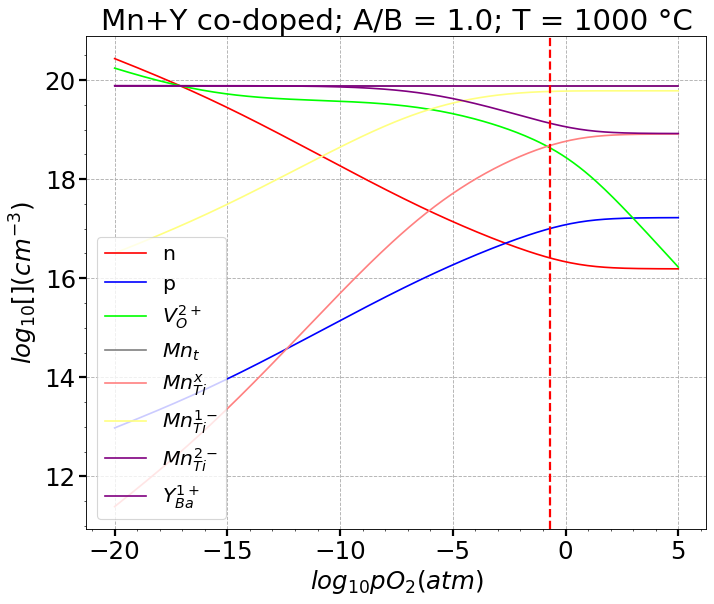

In [11]:
"""
[19] Mn+Y co-doped & A/B = 1.000 & high T eq

Charge neutrality condition: p + 2[VO2+] + [YBa1+] = n + 2[VBa2-] + 4[VTi4-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] = [VTi4-] with full Schottky reaction
"""
ratio = 1.000
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CYt = 7.7E19 # total Y concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CY = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + CMnt + CMnt*(Ki/KMn43)*((Ki/KMn32)*x/Ki - Ki/((Ki/KMn43)*x))/(Ki/x + Ki/KMn43 + (Ki/KMn43)*(Ki/KMn32)*x/Ki) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))) - CYt)
    sol1 = brentq(f,1E10,1E30,maxiter=200)
    
    n_MnY_1000e[i] = np.array(sol1).astype(np.float64)
    p_MnY_1000e[i] = Ki/n_MnY_1000e[i]
    CVO2_MnY_1000e[i] = KR/((n_MnY_1000e[i]**2)*(y**(1/2)))
    CMn1_MnY_1000e[i] = CMnt*(Ki/KMn43)/(p_MnY_1000e[i] + Ki/KMn43 + (Ki/KMn43)*(Ki/KMn32)/p_MnY_1000e[i])
    CMn2_MnY_1000e[i] = (Ki/KMn32)*CMn1_MnY_1000e[i]/p_MnY_1000e[i]
    CMn0_MnY_1000e[i] = CMnt - CMn1_MnY_1000e[i] - CMn2_MnY_1000e[i]
    CY[i] = CYt

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn+Y co-doped; A/B = {ratio}; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_MnY_1000e),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_MnY_1000e), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_MnY_1000e),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000e+CMn2_MnY_1000e+CMn0_MnY_1000e), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_MnY_1000e), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000e), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_MnY_1000e), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.plot(np.log10(a),np.log10(CY), c =[128/255, 0/255, 128/255], label = r'$Y_{Ba}^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn+Y co-doped & A/B = {ratio} & T = {TC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_MnY_1000e[154]:.2e}\n'
    f'p = {p_MnY_1000e[154]:.2e}\n'
    f'[VO2+] = {CVO2_MnY_1000e[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_MnY_1000e[154]:.2e}\n'
    f'[VTi4-] = {CVTi4_MnY_1000e[154]:.2e}\n'
    f'[Mnt] = {CMn1_MnY_1000e[154]+CMn2_MnY_1000e[154]+CMn0_MnY_1000e[154]:.2e}\n'
    f'[Mn0] = {CMn0_MnY_1000e[154]:.2e}\n'
    f'[Mn1-] = {CMn1_MnY_1000e[154]:.2e}\n'
    f'[Mn2-] = {CMn2_MnY_1000e[154]:.2e}\n'
    f'[YBa1+] = {CY[154]:.2e}'
)

Mn+Y co-doped & A/B = 0.999 & T = 1150 °C
at pO2 ~ 0.21 atm
n = 2.26e+16
p = 1.87e+18
[VO2+] = 3.09e+18
[VBa2-] = 1.55e+19
[Mnt] = 7.70e+19
[Mn0] = 2.59e+19
[Mn1-] = 4.82e+19
[Mn2-] = 2.92e+18
[YBa1+] = 7.70e+19


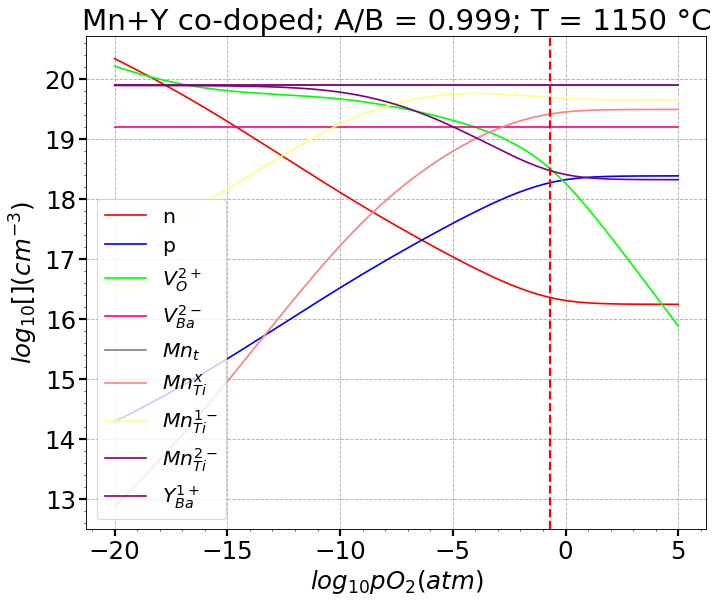

In [17]:
"""
[20] Mn+Y co-doped & A/B = 0.999 & high T eq

Charge neutrality condition: p + 2[VO2+] + [YBa1+] = n + 2[VBa2-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] >> [VTi4-] & [VBa2-] = (1 - A/B_ratio)*1.55E22 cm-3
"""
ratio = 0.999
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CYt = 7.7E19 # total Y concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CY = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*(1 - ratio)*1.55E22 + (CMnt/(KMn43/x + 1 + x/KMn32))*(1 + 2*x/KMn32) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))) - CYt)
    sol1 = brentq(f,1,1E30)
    
    n_MnY_999e[i] = np.array(sol1).astype(np.float64)
    p_MnY_999e[i] = Ki/n_MnY_999e[i]
    CVO2_MnY_999e[i] = KR/((n_MnY_999e[i]**2)*(y**(1/2)))
    CVBa2_MnY_999e[i] = (1 - ratio)*1.55E22
    CMn1_MnY_999e[i] = CMnt/(KMn43/n_MnY_999e[i] + 1 + n_MnY_999e[i]/KMn32)
    CMn2_MnY_999e[i] = CMn1_MnY_999e[i]*n_MnY_999e[i]/KMn32
    CMn0_MnY_999e[i] = CMnt - CMn1_MnY_999e[i] - CMn2_MnY_999e[i]
    CY[i] = CYt

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn+Y co-doped; A/B = {ratio}; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_MnY_999e),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_MnY_999e), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_MnY_999e),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_MnY_999e), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_999e+CMn2_MnY_999e+CMn0_MnY_999e), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_MnY_999e), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_999e), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_MnY_999e), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.plot(np.log10(a),np.log10(CY), c =[128/255, 0/255, 128/255], label = r'$Y_{Ba}^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn+Y co-doped & A/B = {ratio} & T = {TC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_MnY_999e[154]:.2e}\n'
    f'p = {p_MnY_999e[154]:.2e}\n'
    f'[VO2+] = {CVO2_MnY_999e[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_MnY_999e[154]:.2e}\n'
    f'[Mnt] = {CMn1_MnY_999e[154]+CMn2_MnY_999e[154]+CMn0_MnY_999e[154]:.2e}\n'
    f'[Mn0] = {CMn0_MnY_999e[154]:.2e}\n'
    f'[Mn1-] = {CMn1_MnY_999e[154]:.2e}\n'
    f'[Mn2-] = {CMn2_MnY_999e[154]:.2e}\n'
    f'[YBa1+] = {CY[154]:.2e}'
)

Mn+Y co-doped & A/B = 0.994 & T = 1150 °C
at pO2 ~ 0.21 atm
n = 5.06e+15
p = 8.35e+18
[VO2+] = 6.19e+19
[VBa2-] = 9.30e+19
[Mnt] = 7.70e+19
[Mn0] = 5.42e+19
[Mn1-] = 2.25e+19
[Mn2-] = 3.05e+17
[YBa1+] = 7.70e+19


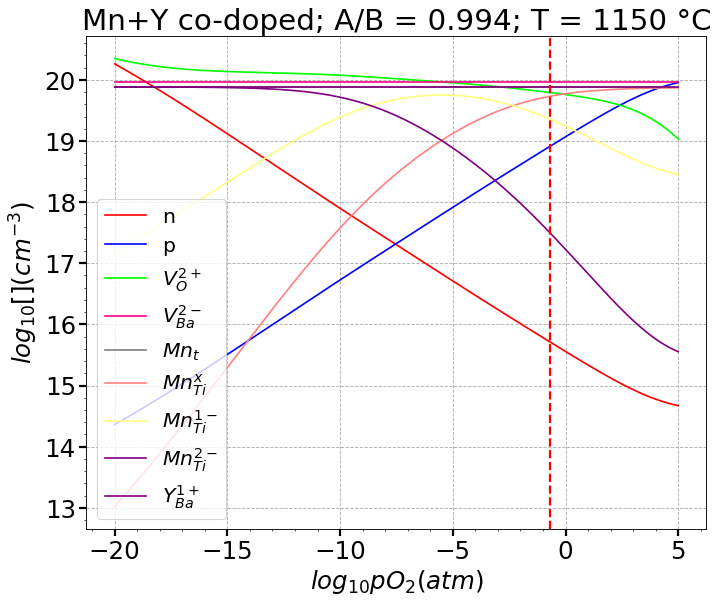

In [7]:
"""
[21] Mn+Y co-doped & A/B = 0.994 & high T eq

Charge neutrality condition: p + 2[VO2+] + [YBa1+] = n + 2[VBa2-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] >> [VTi4-] & [VBa2-] = (1 - A/B_ratio)*1.55E22 cm-3
"""
ratio = 0.994
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CYt = 7.7E19 # total Y concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CY = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*(1 - ratio)*1.55E22 + (CMnt/(KMn43/x + 1 + x/KMn32))*(1 + 2*x/KMn32) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))) - CYt)
    sol1 = brentq(f,1,1E30)
    
    n_MnY_994e[i] = np.array(sol1).astype(np.float64)
    p_MnY_994e[i] = Ki/n_MnY_994e[i]
    CVO2_MnY_994e[i] = KR/((n_MnY_994e[i]**2)*(y**(1/2)))
    CVBa2_MnY_994e[i] = (1 - ratio)*1.55E22
    CMn1_MnY_994e[i] = CMnt/(KMn43/n_MnY_994e[i] + 1 + n_MnY_994e[i]/KMn32)
    CMn2_MnY_994e[i] = CMn1_MnY_994e[i]*n_MnY_994e[i]/KMn32
    CMn0_MnY_994e[i] = CMnt - CMn1_MnY_994e[i] - CMn2_MnY_994e[i]
    CY[i] = CYt

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn+Y co-doped; A/B = {ratio}; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_MnY_994e),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_MnY_994e), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_MnY_994e),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_MnY_994e), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_994e+CMn2_MnY_994e+CMn0_MnY_994e), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_MnY_994e), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_994e), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_MnY_994e), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.plot(np.log10(a),np.log10(CY), c =[128/255, 0/255, 128/255], label = r'$Y_{Ba}^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn+Y co-doped & A/B = {ratio} & T = {TC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_MnY_994e[154]:.2e}\n'
    f'p = {p_MnY_994e[154]:.2e}\n'
    f'[VO2+] = {CVO2_MnY_994e[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_MnY_994e[154]:.2e}\n'
    f'[Mnt] = {CMn1_MnY_994e[154]+CMn2_MnY_994e[154]+CMn0_MnY_994e[154]:.2e}\n'
    f'[Mn0] = {CMn0_MnY_994e[154]:.2e}\n'
    f'[Mn1-] = {CMn1_MnY_994e[154]:.2e}\n'
    f'[Mn2-] = {CMn2_MnY_994e[154]:.2e}\n'
    f'[YBa1+] = {CY[154]:.2e}'
)

/tmp/ipykernel_2903/3517671669.py:42: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CMn0_MnY_1000q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
/tmp/ipykernel_2903/3517671669.py:42: RuntimeWarning: invalid value encountered in log10
  ax1.plot(np.log10(a),np.log10(CMn0_MnY_1000q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')


Mn+Y co-doped & A/B = 1.0 & T = 500 °C
at pO2 ~ 0.21 atm
n = 3.27e+11
p = 2.78e+14
[VO2+] = 4.19e+18
[VBa2-] = 4.10e+18
[VTi4-] = 4.10e+18
[Mnt] = 1.54e+20
[Mn0] = 1.68e+19
[Mn1-] = 1.37e+20
[Mn2-] = 6.30e+17
[YBa1+] = 1.54e+20


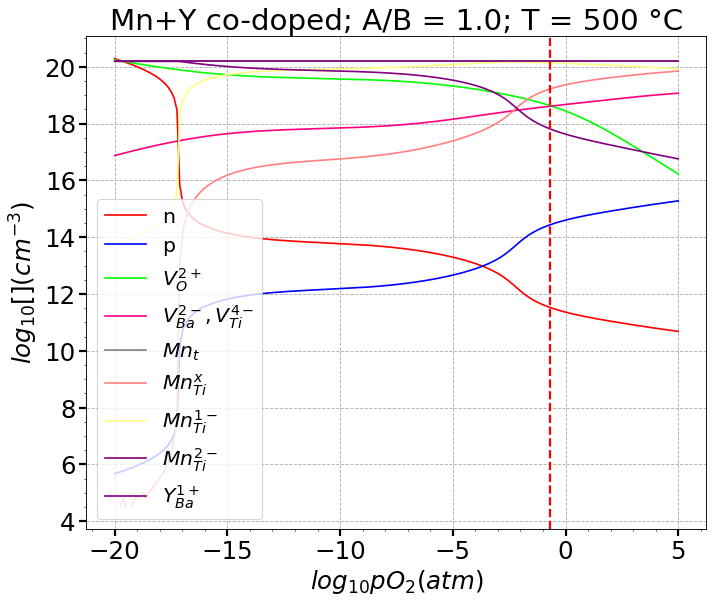

In [15]:
"""
[22] Mn+Y co-doped & A/B = 1.000 & low T quenched

Charge neutrality condition: p + 2[VO2+] + [YBa1+] = n + 2[VBa2-] + 4[VTi4-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] = [VTi4-] with full Schottky reaction & ionic defects (VO2 & VBa2 & VTi4) frozen-in from high T eq to low T quenched state
"""
ratio = 1.000
CMnt = 2*7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CYt = 2*7.7E19 # total Y concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CY = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*CVBa2_MnY_1000e[i] + 4*CVTi4_MnY_1000e[i] + (CMnt/(KMn43Q/x + 1 + x/KMn32Q))*(1 + 2*x/KMn32Q) - (KiQ/x) - 2*CVO2_MnY_1000e[i] - CYt)
    sol1 = brentq(f,1,1E30)
    
    n_MnY_1000q[i] = np.array(sol1).astype(np.float64)
    p_MnY_1000q[i] = KiQ/n_MnY_1000q[i]
    CVO2_MnY_1000q[i] = CVO2_MnY_1000e[i]
    CVTi4_MnY_1000q[i] = CVTi4_MnY_1000e[i]
    CVBa2_MnY_1000q[i] = CVBa2_MnY_1000e[i]
    CMn1_MnY_1000q[i] = CMnt/(KMn43Q/n_MnY_1000q[i] + 1 + n_MnY_1000q[i]/KMn32Q)
    CMn2_MnY_1000q[i] = CMn1_MnY_1000q[i]*n_MnY_1000q[i]/KMn32Q
    CMn0_MnY_1000q[i] = CMnt - CMn1_MnY_1000q[i] - CMn2_MnY_1000q[i]
    CY[i] = CYt

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn+Y co-doped; A/B = {ratio}; T = {TQC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_MnY_1000q),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_MnY_1000q), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_MnY_1000q),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_MnY_1000q), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}, V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000q+CMn2_MnY_1000q+CMn0_MnY_1000q), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_MnY_1000q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000q), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_MnY_1000q), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.plot(np.log10(a),np.log10(CY), c =[128/255, 0/255, 128/255], label = r'$Y_{Ba}^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn+Y co-doped & A/B = {ratio} & T = {TQC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_MnY_1000q[154]:.2e}\n'
    f'p = {p_MnY_1000q[154]:.2e}\n'
    f'[VO2+] = {CVO2_MnY_1000q[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_MnY_1000q[154]:.2e}\n'
    f'[VTi4-] = {CVTi4_MnY_1000q[154]:.2e}\n'
    f'[Mnt] = {CMn1_MnY_1000q[154]+CMn2_MnY_1000q[154]+CMn0_MnY_1000q[154]:.2e}\n'
    f'[Mn0] = {CMn0_MnY_1000q[154]:.2e}\n'
    f'[Mn1-] = {CMn1_MnY_1000q[154]:.2e}\n'
    f'[Mn2-] = {CMn2_MnY_1000q[154]:.2e}\n'
    f'[YBa1+] = {CY[154]:.2e}'
)

Mn+Y co-doped & A/B = 0.999 & T = 900 °C
at pO2 ~ 0.21 atm
n = 1.75e+15
p = 1.54e+17
[VO2+] = 1.30e+18
[VBa2-] = 1.55e+19
[Mnt] = 1.54e+20
[Mn0] = 3.30e+19
[Mn1-] = 1.16e+20
[Mn2-] = 4.77e+18
[YBa1+] = 1.54e+20


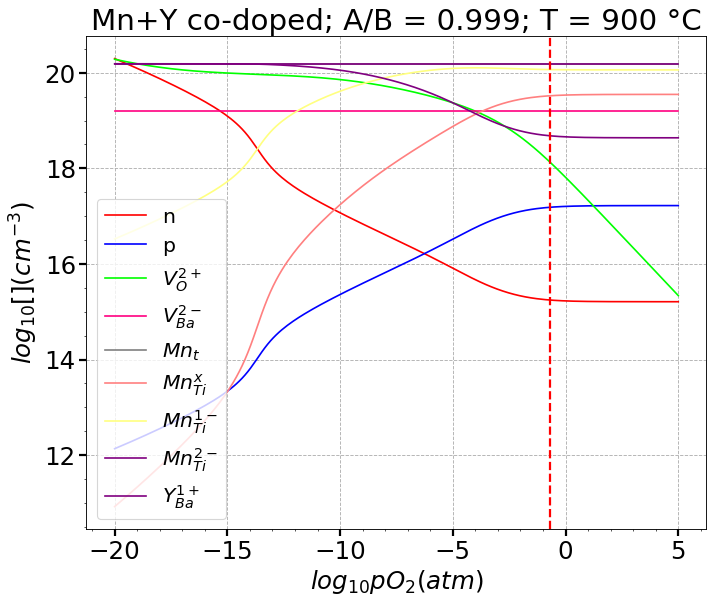

In [8]:
"""
[23] Mn+Y co-doped & A/B = 0.999 & low T quenched

Charge neutrality condition: p + 2[VO2+] + [YBa1+] = n + 2[VBa2-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] >> [VTi4-] & [VBa2-] = (1 - A/B_ratio)*1.55E22 cm-3 & ionic defects (VO2 & VBa2 & VTi4) frozen-in from high T eq to low T quenched state
"""
ratio = 0.999
CMnt = 2*7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CYt = 2*7.7E19 # total Y concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CY = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*CVBa2_MnY_999e[i] + (CMnt/(KMn43Q/x + 1 + x/KMn32Q))*(1 + 2*x/KMn32Q) - (KiQ/x) - 2*CVO2_MnY_999e[i] - CYt)
    sol1 = brentq(f,1,1E30)
    
    n_MnY_999q[i] = np.array(sol1).astype(np.float64)
    p_MnY_999q[i] = KiQ/n_MnY_999q[i]
    CVO2_MnY_999q[i] = CVO2_MnY_999e[i]
    CVBa2_MnY_999q[i] = CVBa2_MnY_999e[i]
    CMn1_MnY_999q[i] = CMnt/(KMn43Q/n_MnY_999q[i] + 1 + n_MnY_999q[i]/KMn32Q)
    CMn2_MnY_999q[i] = CMn1_MnY_999q[i]*n_MnY_999q[i]/KMn32Q
    CMn0_MnY_999q[i] = CMnt - CMn1_MnY_999q[i] - CMn2_MnY_999q[i]
    CY[i] = CYt

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn+Y co-doped; A/B = {ratio}; T = {TQC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_MnY_999q),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_MnY_999q), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_MnY_999q),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_MnY_999q), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_999q+CMn2_MnY_999q+CMn0_MnY_999q), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_MnY_999q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_999q), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_MnY_999q), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.plot(np.log10(a),np.log10(CY), c =[128/255, 0/255, 128/255], label = r'$Y_{Ba}^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn+Y co-doped & A/B = {ratio} & T = {TQC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_MnY_999q[154]:.2e}\n'
    f'p = {p_MnY_999q[154]:.2e}\n'
    f'[VO2+] = {CVO2_MnY_999q[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_MnY_999q[154]:.2e}\n'
    f'[Mnt] = {CMn1_MnY_999q[154]+CMn2_MnY_999q[154]+CMn0_MnY_999q[154]:.2e}\n'
    f'[Mn0] = {CMn0_MnY_999q[154]:.2e}\n'
    f'[Mn1-] = {CMn1_MnY_999q[154]:.2e}\n'
    f'[Mn2-] = {CMn2_MnY_999q[154]:.2e}\n'
    f'[YBa1+] = {CY[154]:.2e}'
)

/tmp/ipykernel_16963/565701424.py:41: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CMn0_MnY_994q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')


Mn+Y co-doped & A/B = 0.994 & T = 500 °C
at pO2 ~ 0.21 atm
n = 9.59e+09
p = 9.50e+15
[VO2+] = 6.19e+19
[VBa2-] = 9.30e+19
[Mnt] = 7.70e+19
[Mn0] = 6.22e+19
[Mn1-] = 1.48e+19
[Mn2-] = 2.00e+15
[YBa1+] = 7.70e+19


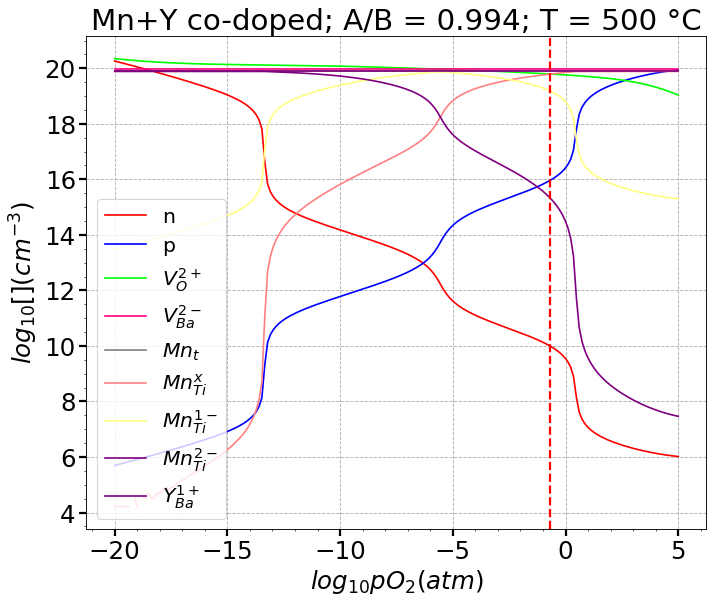

In [10]:
"""
[24] Mn+Y co-doped & A/B = 0.994 & low T quenched

Charge neutrality condition: p + 2[VO2+] + [YBa1+] = n + 2[VBa2-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] >> [VTi4-] & [VBa2-] = (1 - A/B_ratio)*1.55E22 cm-3 & ionic defects (VO2 & VBa2 & VTi4) frozen-in from high T eq to low T quenched state
"""
ratio = 0.994
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CYt = 7.7E19 # total Y concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CY = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*CVBa2_MnY_994e[i] + (CMnt/(KMn43Q/x + 1 + x/KMn32Q))*(1 + 2*x/KMn32Q) - (KiQ/x) - 2*CVO2_MnY_994e[i] - CYt)
    sol1 = brentq(f,1,1E30)
    
    n_MnY_994q[i] = np.array(sol1).astype(np.float64)
    p_MnY_994q[i] = KiQ/n_MnY_994q[i]
    CVO2_MnY_994q[i] = CVO2_MnY_994e[i]
    CVBa2_MnY_994q[i] = CVBa2_MnY_994e[i]
    CMn1_MnY_994q[i] = CMnt/(KMn43Q/n_MnY_994q[i] + 1 + n_MnY_994q[i]/KMn32Q)
    CMn2_MnY_994q[i] = CMn1_MnY_994q[i]*n_MnY_994q[i]/KMn32Q
    CMn0_MnY_994q[i] = CMnt - CMn1_MnY_994q[i] - CMn2_MnY_994q[i]
    CY[i] = CYt

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn+Y co-doped; A/B = {ratio}; T = {TQC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_MnY_994q),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_MnY_994q), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_MnY_994q),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_MnY_994q), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_994q+CMn2_MnY_994q+CMn0_MnY_994q), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_MnY_994q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_994q), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_MnY_994q), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.plot(np.log10(a),np.log10(CY), c =[128/255, 0/255, 128/255], label = r'$Y_{Ba}^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn+Y co-doped & A/B = {ratio} & T = {TQC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_MnY_994q[154]:.2e}\n'
    f'p = {p_MnY_994q[154]:.2e}\n'
    f'[VO2+] = {CVO2_MnY_994q[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_MnY_994q[154]:.2e}\n'
    f'[Mnt] = {CMn1_MnY_994q[154]+CMn2_MnY_994q[154]+CMn0_MnY_994q[154]:.2e}\n'
    f'[Mn0] = {CMn0_MnY_994q[154]:.2e}\n'
    f'[Mn1-] = {CMn1_MnY_994q[154]:.2e}\n'
    f'[Mn2-] = {CMn2_MnY_994q[154]:.2e}\n'
    f'[YBa1+] = {CY[154]:.2e}'
)

In [12]:
import pandas as pd

# Create a dictionary with the data
data = {'Mn+Y doped': [1, 0.999, 0.994],
        TC: [p_MnY_1000e[154], p_MnY_999e[154], p_MnY_994e[154]],
        TQC: [p_MnY_1000q[154], p_MnY_999q[154], p_MnY_994q[154]]}

# Create a DataFrame (table) from the dictionary
df = pd.DataFrame(data)

# Print the table
print(df.to_string(float_format='%.2e'))

   Mn+Y doped     1150      500
0    1.00e+00 4.02e+18 2.98e+15
1    9.99e-01 1.87e+18 1.08e+15
2    9.94e-01 8.35e+18 9.50e+15


In [13]:
print(f'{n_MnY_999q[154]:.2e} {CVO2_MnY_999q[154]:.2e}')

8.44e+10 3.09e+18
